DATA CLEANING

In [3]:
import pandas as pd
import numpy as np

In [4]:
df=pd.read_csv ("C:/Users/DEV/Downloads/shein-products.csv") 
print (df.head())


                                        product_name  \
0  Tall Narrow Bathroom Storage Cabinet With 3 Dr...   
1  1PC Natural Yellow Rainbow Halo Raw Crystal, A...   
2  1PC Sexy Lingerie Body StockingOpen Crotch Hol...   
3  Italian Genuine Leather Thick Belt For Men, Re...   
4  Unbeatablesale Hylomar 61701 13.53 Oz Hylomar ...   

                                         description  initial_price  \
0  Free Returns ✓ Free Shipping✓. Tall Narrow Bat...         120.99   
1  Free Returns ✓ Free Shipping✓. 1PC Natural Yel...           2.10   
2  Free Returns ✓ Free Shipping✓. 1PC Sexy Linger...           3.39   
3  Free Returns ✓ Free Shipping✓. Italian Genuine...          22.80   
4  Free Returns ✓ Free Shipping✓. Unbeatablesale ...          28.53   

   final_price currency  in_stock       color                   size  \
0       120.99      USD      True        Grey               one-size   
1         2.10      USD      True  Multicolor  Electroplated Citrine   
2         2.14      

In [5]:
df.info
df.shape
df.isnull().sum()
(df.isnull().sum() / len(df)) * 100
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.columns


Index(['product_name', 'description', 'initial_price', 'final_price',
       'currency', 'in_stock', 'color', 'size', 'reviews_count', 'main_image',
       'category_url', 'url', 'category_tree', 'country_code', 'domain',
       'image_count', 'image_urls', 'model_number', 'offers',
       'other_attributes', 'product_id', 'rating', 'related_products',
       'root_category', 'top_reviews', 'category', 'brand',
       'all_available_sizes'],
      dtype='str')

In [6]:
df.columns= df.columns.str.strip().str.lower().str.replace(" ","_")
df.columns


Index(['product_name', 'description', 'initial_price', 'final_price',
       'currency', 'in_stock', 'color', 'size', 'reviews_count', 'main_image',
       'category_url', 'url', 'category_tree', 'country_code', 'domain',
       'image_count', 'image_urls', 'model_number', 'offers',
       'other_attributes', 'product_id', 'rating', 'related_products',
       'root_category', 'top_reviews', 'category', 'brand',
       'all_available_sizes'],
      dtype='str')

In [7]:
df['initial_price'] = pd.to_numeric(df['initial_price'], errors='coerce')
df['final_price'] = pd.to_numeric(df['final_price'], errors='coerce')



In [8]:
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

create Discount amount

In [9]:
df['discount_amount'] = df['initial_price'] - df['final_price']

In [10]:
df['discount_percentage'] = (
    (df['initial_price'] - df['final_price']) /
    df['initial_price']
) * 100

In [11]:
df[['initial_price','final_price','rating','reviews_count']].describe()

,initial_price,final_price,rating,reviews_count
count,1000.000000,1000.000000,1000.0,1000.0
mean,33.658100,27.407550,0.0,0.0
std,92.539549,65.960853,0.0,0.0
min,1.100000,0.750000,0.0,0.0
25%,3.300000,2.915000,0.0,0.0
50%,9.600000,8.460000,0.0,0.0
75%,29.990000,26.125000,0.0,0.0
max,1424.300000,1011.200000,0.0,0.0


Handele missing values

In [12]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    median_val = df[col].median()
    df.loc[:, col] = df[col].fillna(median_val)

In [13]:
cat_cols = df.select_dtypes(include=['object', 'string']).columns
for col in cat_cols:
    mode_value = df[col].mode()[0]
    df.loc[:, col] = df[col].fillna(mode_value)

Check outliners

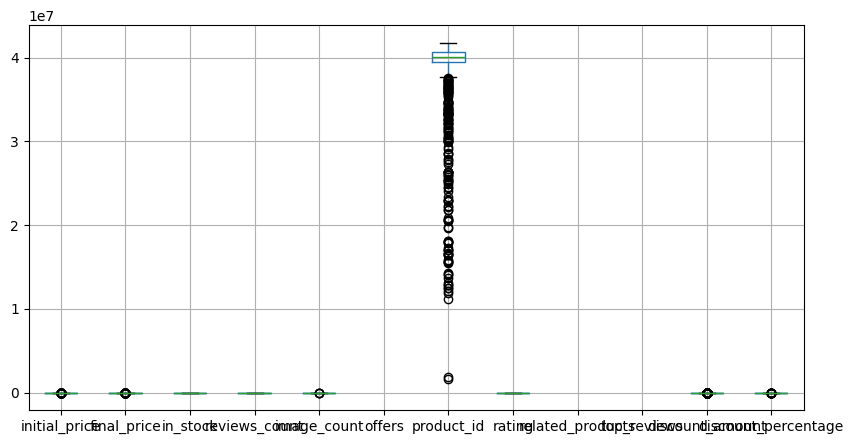

In [14]:
import matplotlib.pyplot as plt

df.boxplot(figsize=(10,5))
plt.show()

Final verification

In [15]:
df.isnull().sum()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_name         1000 non-null   str    
 1   description          1000 non-null   str    
 2   initial_price        1000 non-null   float64
 3   final_price          1000 non-null   float64
 4   currency             1000 non-null   str    
 5   in_stock             1000 non-null   bool   
 6   color                1000 non-null   str    
 7   size                 1000 non-null   str    
 8   reviews_count        1000 non-null   int64  
 9   main_image           1000 non-null   str    
 10  category_url         1000 non-null   str    
 11  url                  1000 non-null   str    
 12  category_tree        1000 non-null   str    
 13  country_code         1000 non-null   str    
 14  domain               1000 non-null   str    
 15  image_count          1000 non-null   int64  
 16  

,initial_price,final_price,reviews_count,image_count,offers,product_id,rating,related_products,top_reviews,discount_amount,discount_percentage
count,1000.000000,1000.000000,1000.0,1000.000000,0.0,1.000000e+03,1000.0,0.0,0.0,1000.000000,1000.000000
mean,33.658100,27.407550,0.0,8.996000,NaN,3.819595e+07,0.0,NaN,NaN,6.250550,11.015922
std,92.539549,65.960853,0.0,5.641437,NaN,5.761205e+06,0.0,NaN,NaN,35.765672,14.166345
min,1.100000,0.750000,0.0,2.000000,NaN,1.685563e+06,0.0,NaN,NaN,0.000000,0.000000
25%,3.300000,2.915000,0.0,4.000000,NaN,3.944237e+07,0.0,NaN,NaN,0.000000,0.000000
50%,9.600000,8.460000,0.0,8.000000,NaN,4.012338e+07,0.0,NaN,NaN,0.200000,4.347826
75%,29.990000,26.125000,0.0,12.000000,NaN,4.065828e+07,0.0,NaN,NaN,1.250000,19.142554
max,1424.300000,1011.200000,0.0,30.000000,NaN,4.178015e+07,0.0,NaN,NaN,600.000000,73.803856


In [16]:
df.to_csv("shein_cleaned.csv",index = False)

In [17]:
print(df.shape)
print(df.info())
print(df.describe())

(1000, 30)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_name         1000 non-null   str    
 1   description          1000 non-null   str    
 2   initial_price        1000 non-null   float64
 3   final_price          1000 non-null   float64
 4   currency             1000 non-null   str    
 5   in_stock             1000 non-null   bool   
 6   color                1000 non-null   str    
 7   size                 1000 non-null   str    
 8   reviews_count        1000 non-null   int64  
 9   main_image           1000 non-null   str    
 10  category_url         1000 non-null   str    
 11  url                  1000 non-null   str    
 12  category_tree        1000 non-null   str    
 13  country_code         1000 non-null   str    
 14  domain               1000 non-null   str    
 15  image_count          1000 non-null   in

In [18]:
df.isnull().sum().sort_values(ascending=False)

related_products       1000
offers                 1000
top_reviews            1000
initial_price             0
product_name              0
description               0
color                     0
size                      0
reviews_count             0
main_image                0
category_url              0
final_price               0
currency                  0
in_stock                  0
country_code              0
category_tree             0
url                       0
domain                    0
model_number              0
other_attributes          0
image_urls                0
image_count               0
rating                    0
product_id                0
root_category             0
category                  0
brand                     0
all_available_sizes       0
discount_amount           0
discount_percentage       0
dtype: int64

Visaualize missing values

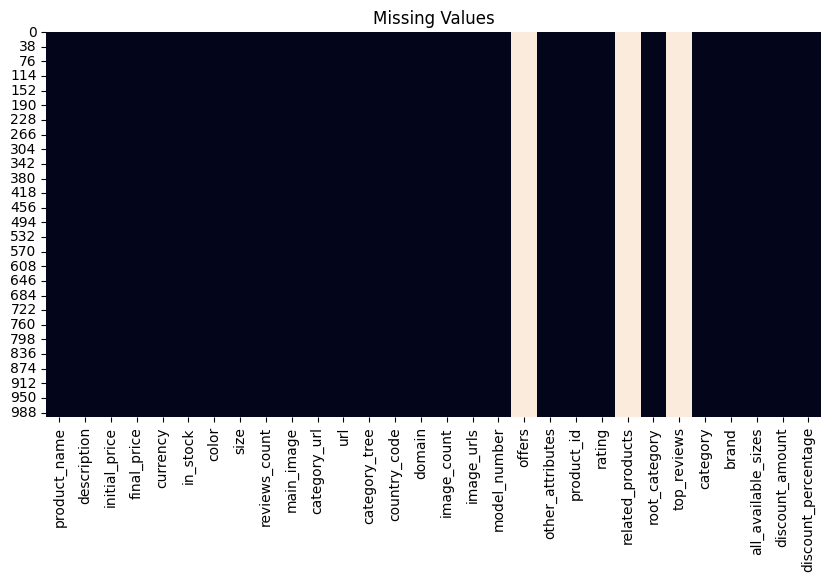

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

PRICE ANALYSIS

Distribution of final price

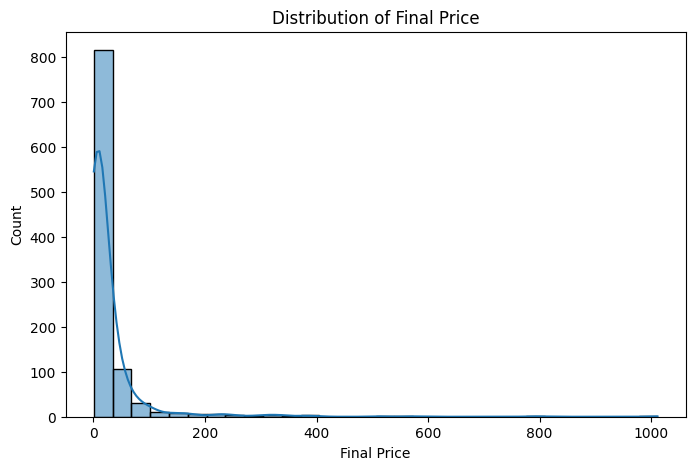

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(df['final_price'], bins=30, kde=True)

plt.title("Distribution of Final Price")
plt.xlabel("Final Price")
plt.show()

TOP 10 most expensive products

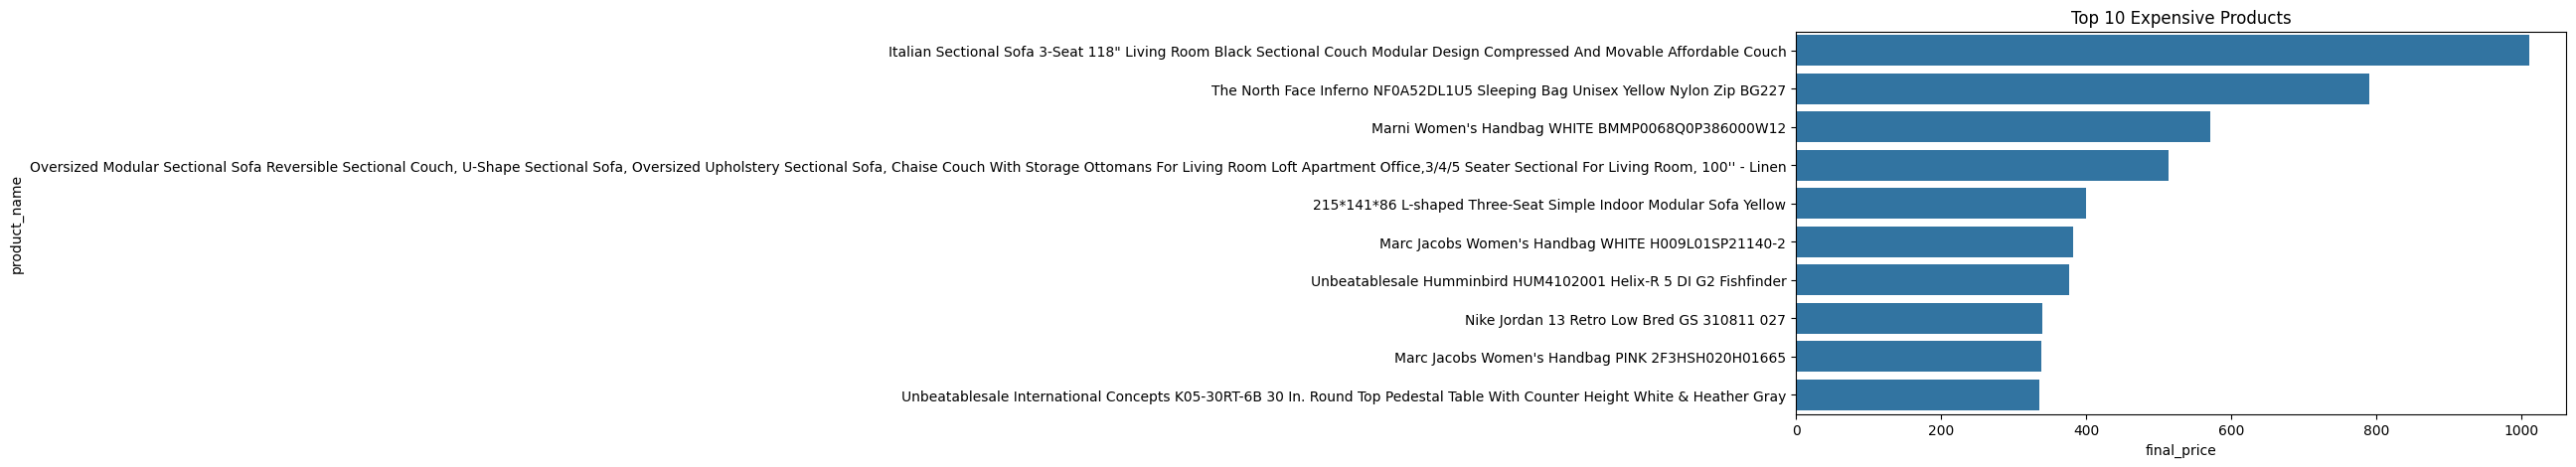

In [21]:
top_price = df.nlargest(10, 'final_price')

plt.figure(figsize=(10,5))
sns.barplot(
    x='final_price',
    y='product_name',
    data=top_price
)

plt.title("Top 10 Expensive Products")
plt.show()

Discount Analysis

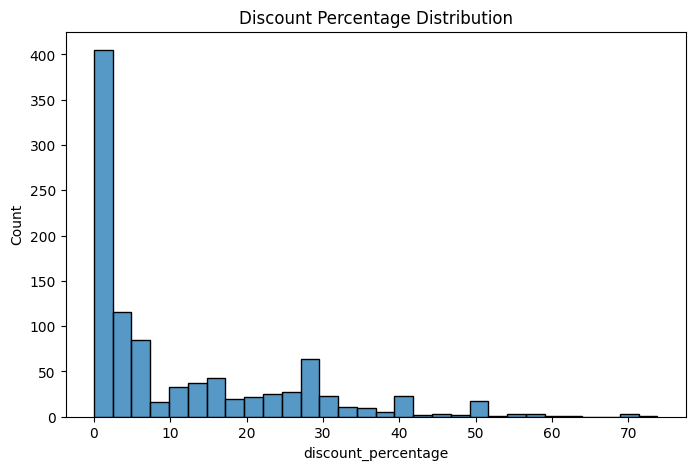

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(df['discount_percentage'], bins=30)

plt.title("Discount Percentage Distribution")
plt.show()

Average discount by category

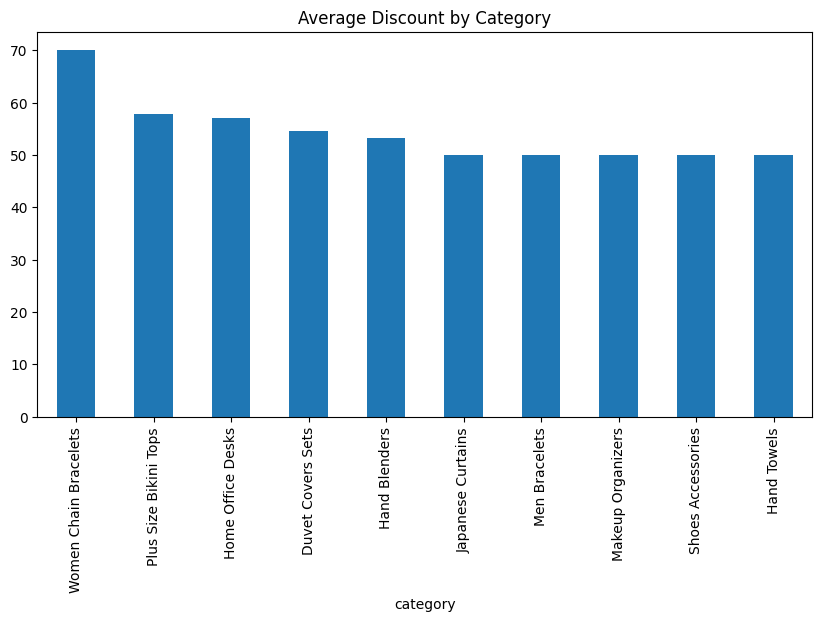

In [23]:
category_discount = (
    df.groupby('category')['discount_percentage']
      .mean()
      .sort_values(ascending=False)
)

category_discount.head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Average Discount by Category")
plt.show()

RATING ANALYSIS

Rating distribution

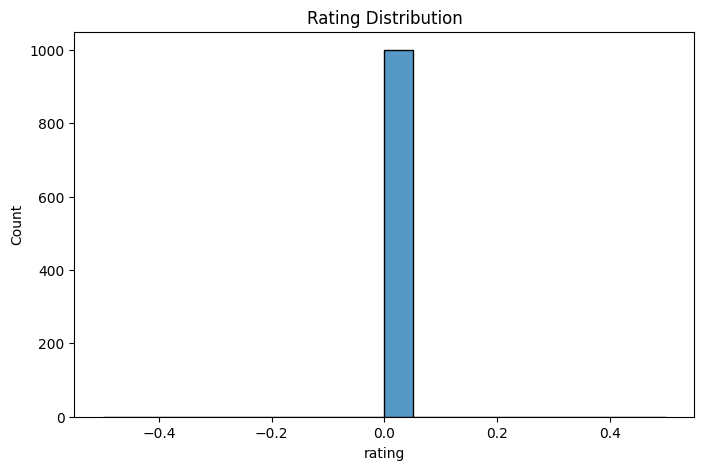

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(df['rating'], bins=20)

plt.title("Rating Distribution")
plt.show()

Top rated product

In [25]:
df.sort_values(
    by='rating',
    ascending=False
)[['product_name','rating']].head(10)

,product_name,rating
0,Tall Narrow Bathroom Storage Cabinet With 3 Dr...,0
1,"1PC Natural Yellow Rainbow Halo Raw Crystal, A...",0
2,1PC Sexy Lingerie Body StockingOpen Crotch Hol...,0
3,"Italian Genuine Leather Thick Belt For Men, Re...",0
4,Unbeatablesale Hylomar 61701 13.53 Oz Hylomar ...,0
5,"1 Set Cup & Saucer, Cute Cat Pattern, High-End...",0
6,Unbeatablesale PIX North America MXV4-410 0.5 ...,0
7,"30pcs,40in Rocket Balloons 6 Assorted Colors F...",0
8,20pcs Artificial Green Plant Leaves Valentine'...,0
9,"10pcs Transparent Baking Boxes With Window, De...",0


REVIEWS ANALYSIS

Most reviewed product

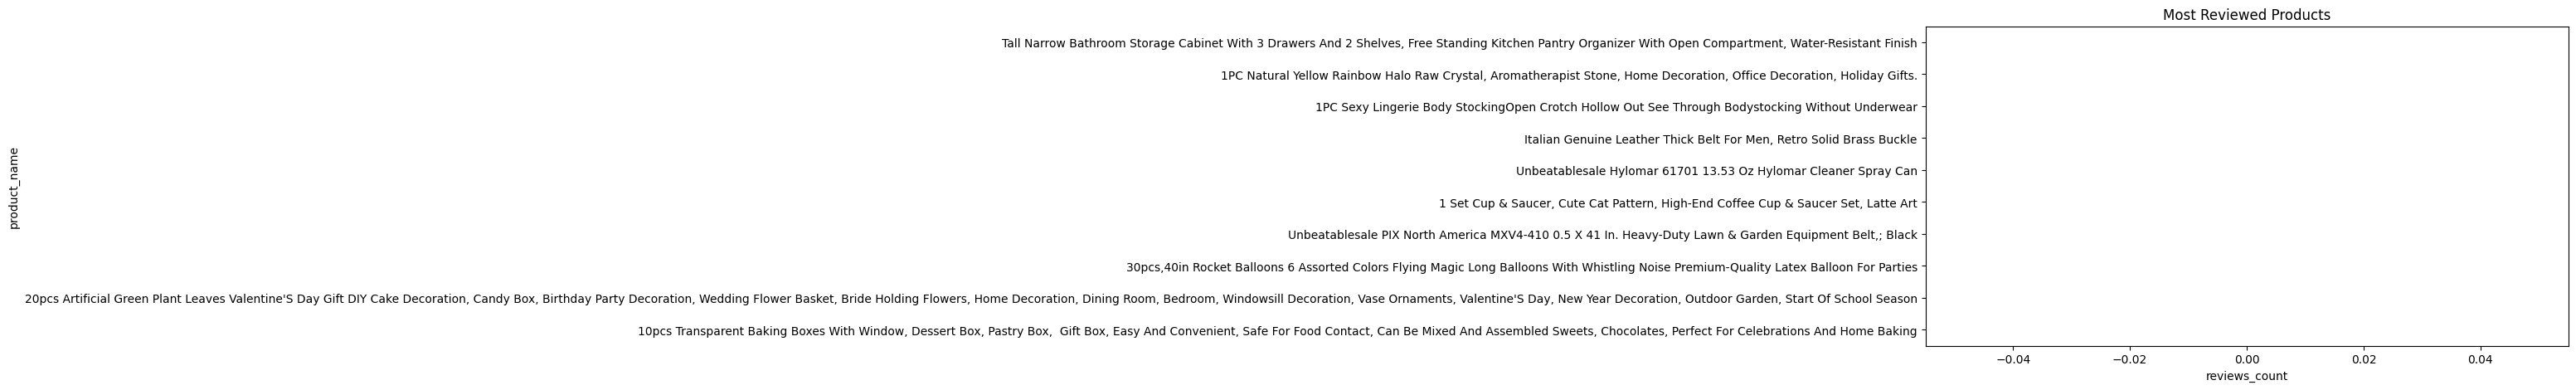

In [26]:
top_reviews = df.nlargest(
    10,
    'reviews_count'
)

plt.figure(figsize=(10,5))
sns.barplot(
    x='reviews_count',
    y='product_name',
    data=top_reviews
)

plt.title("Most Reviewed Products")
plt.show()

RELATIONNSHIP ANALYSIS

Rating vs Reviews

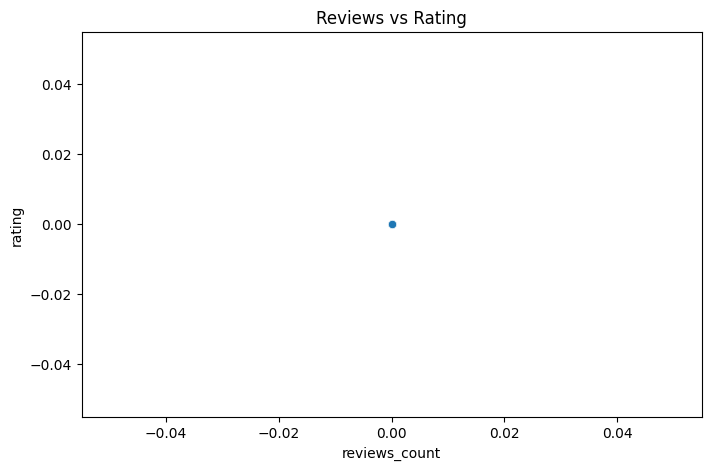

In [27]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='reviews_count',
    y='rating',
    data=df
)

plt.title("Reviews vs Rating")
plt.show()

Final price vs Rating

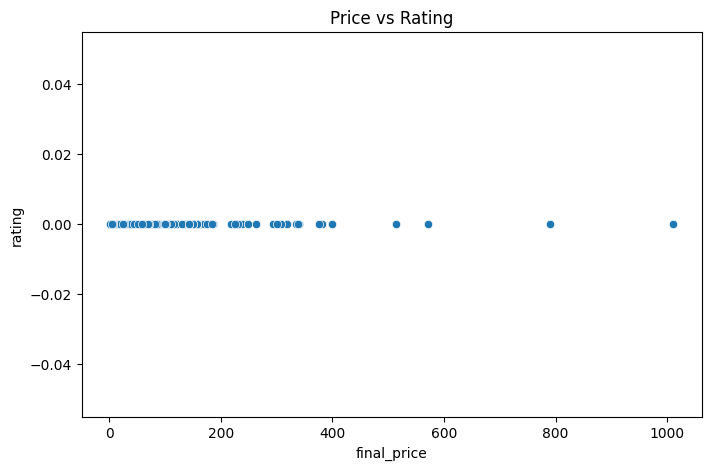

In [28]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='final_price',
    y='rating',
    data=df
)

plt.title("Price vs Rating")
plt.show()

CORRELATION ANALYSIS

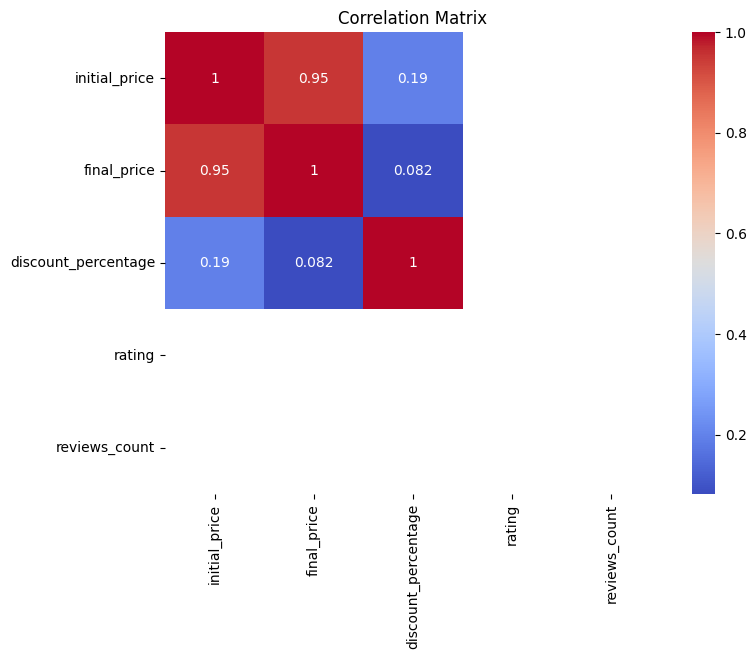

In [29]:
numeric_cols = [
    'initial_price',
    'final_price',
    'discount_percentage',
    'rating',
    'reviews_count'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

In [30]:
df['discount_percentage'] = df['discount_percentage'].astype(str).str.replace('%','').astype(float)